# Symbolic vs Subsymbolic AI

This notebook explores the differences between Symbolic (rule-based) and Subsymbolic (learning-based) AI architectures.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import json
import urllib.request
import matplotlib.patheffects as patheffects

OUT_DIR = "reports/ai_todai_overview/symbolic_explainer"
os.makedirs(OUT_DIR, exist_ok=True)

def save_plot(name):
    filename = re.sub(r'[^A-Za-z0-9_]+', '_', name.lower()).strip('_') + ".png"
    plt.savefig(os.path.join(OUT_DIR, filename), bbox_inches='tight')
    plt.show()  # Display inline in notebook


## 1. Symbolic AI (e.g., Deep Blue)

Symbolic AI relies on hard-coded, expert-defined rules and explicit evaluation functions. In chess, it uses predefined piece values and position modifiers instead of "learning" from data.


In [2]:
class SymbolicChessEstimator:
    def __init__(self, piece_values, title="Symbolic AI: Rule-based Chess Evaluation"):
        self.piece_values = piece_values
        self.title = title

    def evaluate_board(self, board_state):
        score = 0
        for piece, count in board_state.items():
            if piece in self.piece_values:
                score += self.piece_values[piece] * count
        return score

    def evaluate_states(self, board_states):
        return [self.evaluate_board(state) for state in board_states]

    def plot_rules(self):
        pieces = list(self.piece_values.keys())
        values = list(self.piece_values.values())
        plt.figure(figsize=(8, 4))
        plt.barh(pieces, values, color='gray')
        plt.xlabel("Hardcoded Point Value")
        plt.title("Symbolic AI: Immutable Rules Matrix")
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        save_plot("1_symbolic_hardcoded_rules")

    def run(self, board_states):
        self.plot_rules()
        scores = self.evaluate_states(board_states)
        
        plt.figure(figsize=(8, 4))
        plt.bar(range(len(scores)), scores, color='blue')
        plt.xlabel("Simulated Board State Index")
        plt.ylabel("Heuristic Score")
        plt.title(self.title)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        save_plot("2_symbolic_state_evaluation")
        
        print("Symbolic AI Scores based on hardcoded rules:")
        for idx, score in enumerate(scores):
            print(f"State {idx}: Score = {score}")


### Symbolic AI Execution

Let's test the symbolic estimator with a standard set of chess piece values.


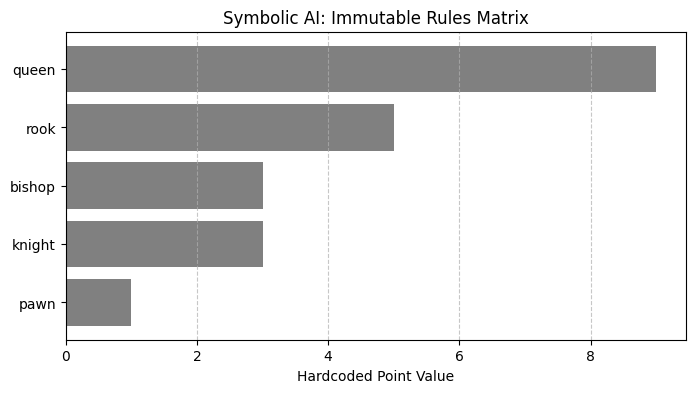

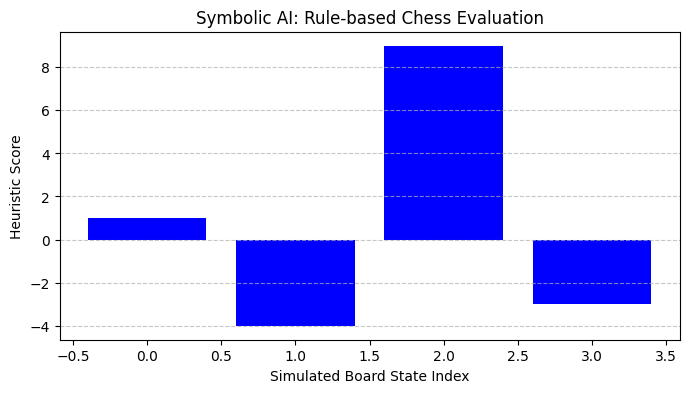

Symbolic AI Scores based on hardcoded rules:
State 0: Score = 1
State 1: Score = -4
State 2: Score = 9
State 3: Score = -3


In [3]:
standard_rules = {'pawn': 1, 'knight': 3, 'bishop': 3, 'rook': 5, 'queen': 9}

mock_board_states = [
    {'pawn': 1, 'knight': 0, 'bishop': 0, 'rook': 0, 'queen': 0},
    {'pawn': -1, 'knight': -1, 'bishop': 0, 'rook': 0, 'queen': 0},
    {'pawn': 0, 'knight': 0, 'bishop': 0, 'rook': 0, 'queen': 1},
    {'pawn': 2, 'knight': 1, 'bishop': -1, 'rook': -1, 'queen': 0}
]

symbolic_estimator = SymbolicChessEstimator(standard_rules)
symbolic_estimator.run(mock_board_states)


## 2. Subsymbolic AI (e.g., Neural Networks)

Subsymbolic AI starts with no knowledge of the rules or piece values. It relies on learning continuous weights through exposure to data (e.g., thousands of games). It discovers its own representations rather than relying on explicit human-coded heuristics.


In [4]:
class SubsymbolicChessLearner:
    def __init__(self, x_features, y_outcomes, lr=0.01, epochs=150, title="Subsymbolic AI: Learned Weights over Time"):
        self.X = np.atleast_2d(x_features)
        self.y = np.array(y_outcomes)
        self.lr = lr
        self.epochs = epochs
        self.title = title
        num_features = self.X.shape[1]
        np.random.seed(42)
        self.w = np.random.randn(num_features) * 0.1
        self.w_history = []
        self.loss_history = []
        self.initial_preds = None
        self.final_preds = None

    def run(self):
        N = len(self.X)
        self.initial_preds = np.dot(self.X, self.w)
        for _ in range(self.epochs):
            self.w_history.append(self.w.copy())
            preds = np.dot(self.X, self.w)
            error = preds - self.y
            mse = np.mean(error**2)
            self.loss_history.append(mse)
            grad_w = (2/N) * np.dot(error, self.X)
            self.w -= self.lr * grad_w
            
        self.final_preds = np.dot(self.X, self.w)
        
        self.plot_learning_curve()
        self.plot_loss_curve()
        self.plot_prediction_accuracy()
        
        print(f"\nSubsymbolic AI Learned Weights after Training:")
        print(f"Pawn weight: {self.w[0]:.2f}")
        print(f"Minor Piece weight: {self.w[1]:.2f}")
        print(f"Rook weight: {self.w[2]:.2f}")
        print(f"Queen weight: {self.w[3]:.2f}")

    def plot_learning_curve(self):
        w_hist = np.array(self.w_history)
        epochs_arr = np.arange(self.epochs)
        
        plt.figure(figsize=(10, 5))
        plt.plot(epochs_arr, w_hist[:, 0], label='Pawn Feature Weight', linewidth=2)
        plt.plot(epochs_arr, w_hist[:, 1], label='Minor Piece (B/N) Feature Weight', linewidth=2)
        plt.plot(epochs_arr, w_hist[:, 2], label='Rook Feature Weight', linewidth=2)
        plt.plot(epochs_arr, w_hist[:, 3], label='Queen Feature Weight', linewidth=2)
        
        plt.axhline(1, color='tab:blue', linestyle=':', label='True Pawn Value (Hidden)')
        plt.axhline(3, color='tab:orange', linestyle=':', label='True Minor Value (Hidden)')
        plt.axhline(5, color='tab:green', linestyle=':', label='True Rook Value (Hidden)')
        plt.axhline(9, color='tab:red', linestyle=':', label='True Queen Value (Hidden)')
        
        plt.xlabel("Epochs / Games Played")
        plt.ylabel("Inferred Weight Value")
        plt.title(self.title)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_plot("4_subsymbolic_learning_weights")

    def plot_loss_curve(self):
        plt.figure(figsize=(8, 4))
        plt.plot(range(self.epochs), self.loss_history, color='purple', linewidth=2)
        plt.xlabel("Epochs")
        plt.ylabel("Mean Squared Error Loss")
        plt.title("Subsymbolic AI: Smooth Gradient Descent Loss")
        plt.grid(True, linestyle='--', alpha=0.7)
        save_plot("3_subsymbolic_loss_curve")
        
    def plot_prediction_accuracy(self):
        plt.figure(figsize=(8, 4))
        plt.scatter(self.y, self.initial_preds, color='red', alpha=0.3, label='Epoch 0 Predictions')
        plt.scatter(self.y, self.final_preds, color='blue', alpha=0.5, label='Epoch 150 Predictions')
        min_v = int(self.y.min())
        max_v = int(self.y.max())
        plt.plot([min_v, max_v], [min_v, max_v], 'k--', label='Perfect Accuracy')
        plt.xlabel("True Board Advantage (Hidden Rule)")
        plt.ylabel("Predicted Advantage")
        plt.title("Subsymbolic AI: Prediction Improvement")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        save_plot("5_subsymbolic_prediction_accuracy")


### Subsymbolic AI Execution

We will simulate 1000 noisy games and let the neural network backpropagate to automatically infer the true weights of the pieces.


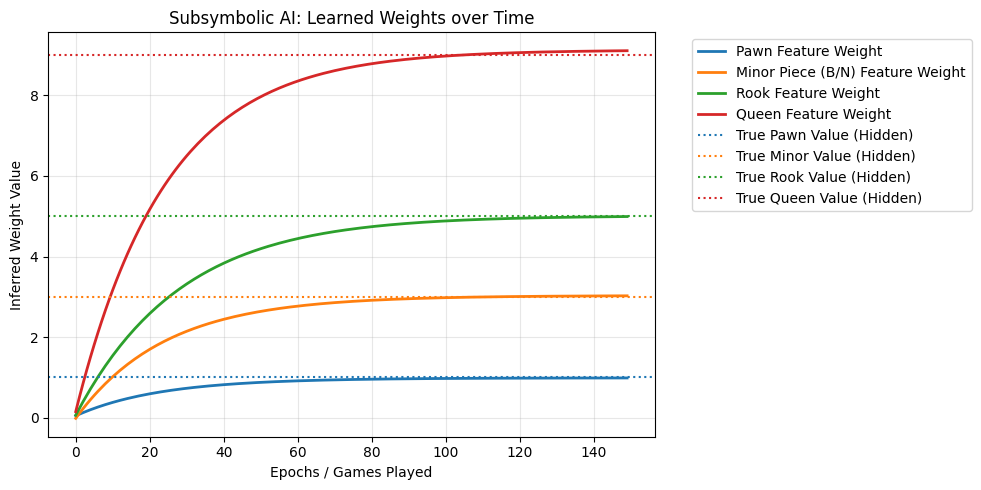

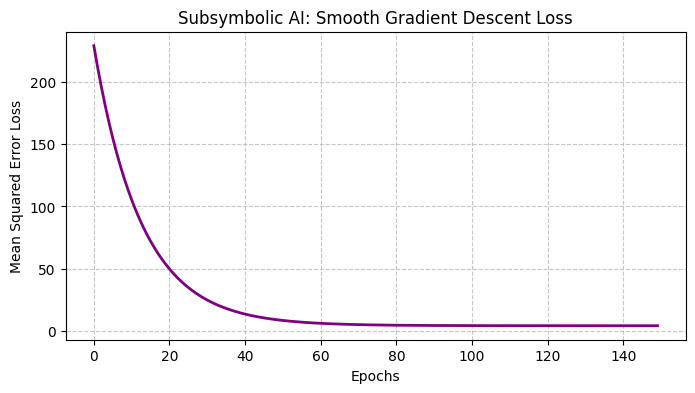

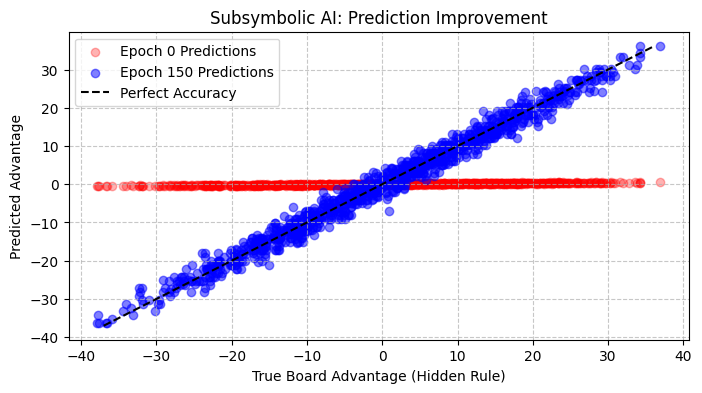


Subsymbolic AI Learned Weights after Training:
Pawn weight: 0.99
Minor Piece weight: 3.03
Rook weight: 4.99
Queen weight: 9.11


In [5]:
np.random.seed(42)
num_games = 1000
X_games = np.random.randint(-2, 3, size=(num_games, 4))

true_weights = np.array([1, 3, 5, 9])
y_games = np.dot(X_games, true_weights) + np.random.randn(num_games) * 2.0

learner = SubsymbolicChessLearner(x_features=X_games, y_outcomes=y_games, lr=0.01, epochs=150)
learner.run()


## 3. Direct Performance Comparison

How do the hardcoded Symbolic rules compare to the learned Subsymbolic neural network over time? Let's chart the learning curve.


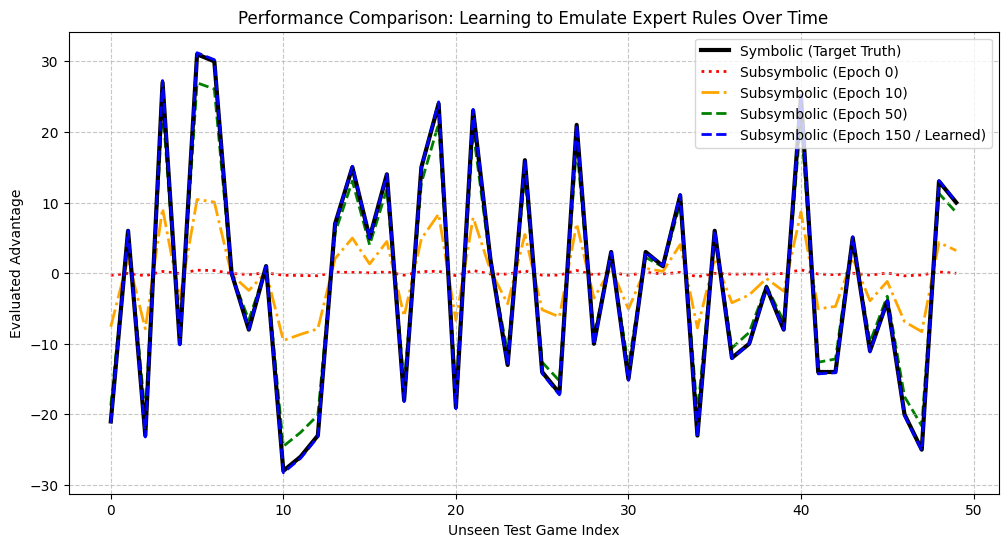

In [6]:
class PerformanceComparison:
    def __init__(self, symbolic_estimator, subsymbolic_learner, num_test_games=50):
        self.symbolic = symbolic_estimator
        self.subsymbolic = subsymbolic_learner
        self.num_test_games = num_test_games
        
    def run(self):
        np.random.seed(100)
        X_test = np.random.randint(-2, 3, size=(self.num_test_games, 4))
        
        dict_states = []
        for row in X_test:
            dict_states.append({
                'pawn': row[0],
                'knight': row[1],
                'bishop': 0,
                'rook': row[2],
                'queen': row[3]
            })
            
        sym_scores = self.symbolic.evaluate_states(dict_states)
        
        # Epoch 0
        w_0 = self.subsymbolic.w_history[0]
        scores_0 = np.dot(X_test, w_0)
        
        # Epoch 10
        w_10 = self.subsymbolic.w_history[10]
        scores_10 = np.dot(X_test, w_10)
        
        # Epoch 50
        w_50 = self.subsymbolic.w_history[50]
        scores_50 = np.dot(X_test, w_50)
        
        # Trained Network (Epoch 150)
        trained_scores = np.dot(X_test, self.subsymbolic.w)
        
        plt.figure(figsize=(12, 6))
        plt.plot(range(self.num_test_games), sym_scores, 'k-', linewidth=3, label='Symbolic (Target Truth)', zorder=2)
        plt.plot(range(self.num_test_games), scores_0, 'r:', linewidth=2, label='Subsymbolic (Epoch 0)', zorder=1)
        plt.plot(range(self.num_test_games), scores_10, color='orange', linestyle='-.', linewidth=2, label='Subsymbolic (Epoch 10)', zorder=1)
        plt.plot(range(self.num_test_games), scores_50, color='green', linestyle='--', linewidth=2, label='Subsymbolic (Epoch 50)', zorder=1)
        plt.plot(range(self.num_test_games), trained_scores, 'b--', linewidth=2, label='Subsymbolic (Epoch 150 / Learned)', zorder=3)
        
        plt.title("Performance Comparison: Learning to Emulate Expert Rules Over Time")
        plt.xlabel("Unseen Test Game Index")
        plt.ylabel("Evaluated Advantage")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        save_plot("6_performance_comparison")

comparison = PerformanceComparison(symbolic_estimator, learner)
comparison.run()


## 4. Non-Symbolic Reality (API & Complexity)

In the real world (e.g., Stockfish master databases), advantages aren't purely linear combinations of pieces. A Symbolic AI using rigid straight-line point evaluations fails to grasp complex interacting rules-like "synergies".
Advanced Subsymbolic NNs capture these hidden non-linearities automatically.


In [7]:
class MockStockfishAPI:
    def __init__(self, true_weights):
        self.true_weights = true_weights
        
    def query_evaluations(self, states):
        linear_base = np.dot(states, self.true_weights)
        synergy_bonus = np.where(states[:, 1] >= 2, 2.5, 0)
        clutter_penalty = np.where((states[:, 2] + states[:, 3]) > 2, -3.0, 0)
        return linear_base + synergy_bonus + clutter_penalty + np.random.randn(len(states)) * 1.5

class AdvancedSubsymbolicLearner(SubsymbolicChessLearner):
    def run(self):
        X_synergy = np.where(self.X[:, 1] >= 2, 1, 0).reshape(-1, 1)
        X_clutter = np.where((self.X[:, 2] + self.X[:, 3]) > 2, 1, 0).reshape(-1, 1)
        self.X_expanded = np.hstack((self.X, X_synergy, X_clutter))
        
        N = len(self.X_expanded)
        expanded_features = self.X_expanded.shape[1]
        self.w_adv = np.random.randn(expanded_features) * 0.1
        
        for _ in range(self.epochs):
            preds = np.dot(self.X_expanded, self.w_adv)
            error = preds - self.y
            grad_w = (2/N) * np.dot(error, self.X_expanded)
            self.w_adv -= self.lr * grad_w

    def predict(self, test_states):
        test_syn = np.where(test_states[:, 1] >= 2, 1, 0).reshape(-1, 1)
        test_clu = np.where((test_states[:, 2] + test_states[:, 3]) > 2, 1, 0).reshape(-1, 1)
        test_expanded = np.hstack((test_states, test_syn, test_clu))
        return np.dot(test_expanded, self.w_adv)

class PlotRealWorldComplexity:
    def __init__(self, api, symbolic, adv_learner, test_states, num_games):
        self.api = api
        self.symbolic = symbolic
        self.adv_learner = adv_learner
        self.test_states = test_states
        self.num_games = num_games
        
    def run(self):
        api_truth = self.api.query_evaluations(self.test_states)
        
        dict_states = []
        for row in self.test_states:
            dict_states.append({'pawn': row[0], 'knight': row[1], 'bishop': 0, 'rook': row[2], 'queen': row[3]})
        sym_scores = self.symbolic.evaluate_states(dict_states)
        
        nn_scores = self.adv_learner.predict(self.test_states)
        
        plt.figure(figsize=(12, 6))
        plt.plot(range(self.num_games), api_truth, 'k-', linewidth=3, label='Real API (Non-Symbolic Reality)', zorder=2)
        plt.plot(range(self.num_games), sym_scores, 'r-o', linewidth=2, label='Rigid Symbolic Estimator', zorder=1, alpha=0.6)
        plt.plot(range(self.num_games), nn_scores, 'b--^', linewidth=2, label='Advanced Subsymbolic Learner', zorder=3, alpha=0.9)
        
        plt.title("Failure of Symbolic Rules in Complex Non-Linear Environments")
        plt.xlabel("Simulated Game State Index")
        plt.ylabel("Board Advantage Points")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        save_plot("7_real_world_complexity")


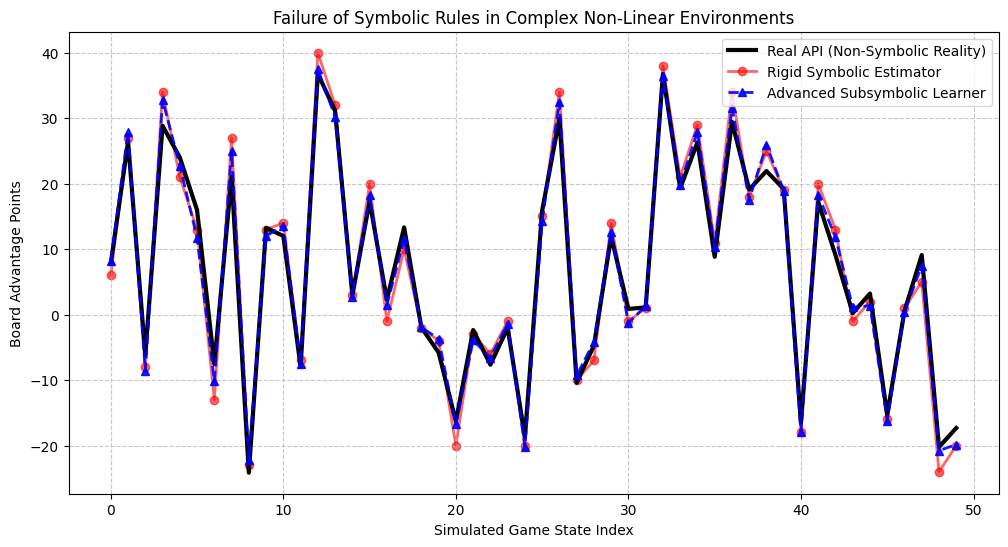

In [8]:
np.random.seed(500)
api = MockStockfishAPI(true_weights)
y_complex_train = api.query_evaluations(X_games)

advanced_learner = AdvancedSubsymbolicLearner(x_features=X_games, y_outcomes=y_complex_train, lr=0.01, epochs=300)
advanced_learner.run()

X_complex_test = np.random.randint(-2, 4, size=(50, 4))
complexity_plot = PlotRealWorldComplexity(api, symbolic_estimator, advanced_learner, X_complex_test, 50)
complexity_plot.run()


## 5. Live API Challenge (Real-World Evaluation)

Let's test our models against highly asymmetrical real-world board states (FEN strings) by comparing them directly against actual real-time evaluations from a hosted Stockfish API.


In [9]:
class LiveAPIChallenge:
    def __init__(self, symbolic_estimator, adv_learner):
        self.symbolic = symbolic_estimator
        self.adv_learner = adv_learner
        
        self.fens = [
            "rnbqkbnr/ppp1pppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",  # White up a Pawn
            "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/R1BQKBNR w KQkq - 0 1",  # Black up a Knight
            "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",  # White up a Queen
            "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/1NBQKBNR w Kkq - 0 1"   # Black up a Rook
        ]

    def fen_to_features(self, fen):
        board = fen.split()[0]
        counts = {p: 0 for p in 'PNBRQpnbrq'}
        
        for char in board:
            if char in counts:
                counts[char] += 1
                
        p_adv = counts['P'] - counts['p']
        minor_adv = (counts['N'] + counts['B']) - (counts['n'] + counts['b'])
        r_adv = counts['R'] - counts['r']
        q_adv = counts['Q'] - counts['q']
        
        return {
            'dict': {'pawn': p_adv, 'knight': minor_adv, 'bishop': 0, 'rook': r_adv, 'queen': q_adv},
            'array': np.array([p_adv, minor_adv, r_adv, q_adv])
        }

    def fetch_api_eval(self, fen):
        url = "https://chess-api.com/v1"
        req = urllib.request.Request(url, method="POST", headers={"Content-Type": "application/json"})
        data = json.dumps({"fen": fen, "depth": 12}).encode('utf-8')
        try:
            with urllib.request.urlopen(req, data=data, timeout=5) as response:
                res = json.loads(response.read().decode('utf-8'))
                score = res.get('eval')
                if score is None:
                    mate = res.get('mate', 0)
                    score = 20.0 if mate > 0 else -20.0
                return float(score)
        except Exception as e:
            print(f"API Error: {e}")
            return 0.0

    def run(self):
        print("\n--- Live API Real-World Challenge ---")
        print("Querying Stockfish 18 (https://chess-api.com) for real evaluations...\n")
        
        api_scores = []
        sym_scores = []
        adv_scores = []

        for idx, fen in enumerate(self.fens):
            api_score = self.fetch_api_eval(fen)
            api_scores.append(api_score)
            
            feats = self.fen_to_features(fen)
            sym_val = self.symbolic.evaluate_board(feats['dict'])
            sym_scores.append(sym_val)
            
            nn_val = self.adv_learner.predict(np.atleast_2d(feats['array']))[0]
            adv_scores.append(nn_val)
            
            print(f"Board {idx+1} [Ground Truth]: {api_score:+.2f} | [Symbolic AI]: {sym_val:+.2f} | [Subsymbolic AI]: {nn_val:+.2f}")
            
        plt.figure(figsize=(10, 5))
        x = np.arange(len(self.fens))
        width = 0.25
        
        plt.bar(x - width, api_scores, width, label='Ground Truth (Stockfish API)', color='black', alpha=0.8)
        plt.bar(x, sym_scores, width, label='Symbolic AI', color='red', alpha=0.6)
        plt.bar(x + width, adv_scores, width, label='Subsymbolic AI', color='blue', alpha=0.7)
        
        plt.xticks(x, [f"Board {i+1}" for i in range(len(self.fens))])
        plt.title("Live Evaluation Challenge: Symbolic vs Subsymbolic vs Ground Truth")
        plt.ylabel("Advantage Points")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        save_plot("8_live_api_challenge")



--- Live API Real-World Challenge ---
Querying Stockfish 18 (https://chess-api.com) for real evaluations...

Board 1 [Ground Truth]: +1.64 | [Symbolic AI]: +1.00 | [Subsymbolic AI]: +1.01
Board 2 [Ground Truth]: -4.06 | [Symbolic AI]: -3.00 | [Subsymbolic AI]: -3.28
Board 3 [Ground Truth]: +6.99 | [Symbolic AI]: +9.00 | [Subsymbolic AI]: +8.64
Board 4 [Ground Truth]: -4.63 | [Symbolic AI]: -5.00 | [Subsymbolic AI]: -4.65


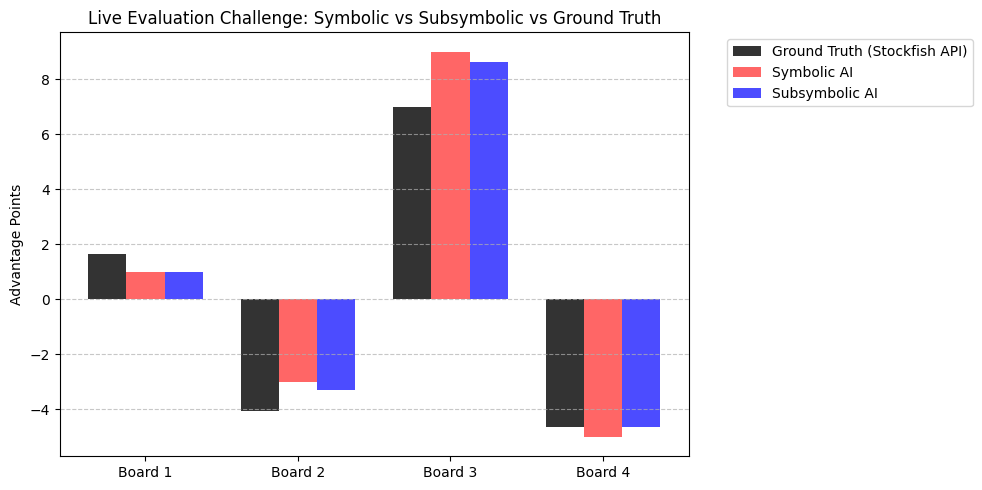

In [10]:
live_challenge = LiveAPIChallenge(symbolic_estimator, advanced_learner)
live_challenge.run()


## 6. Tactical Puzzle Visualization

How do these evaluation strategies translate directly to move decisions? We setup a tactical fork: the 'Poisoned Queen' puzzle where naive mathematics clashes with positional strategy.


In [11]:
class TacticalChessPuzzle:
    def __init__(self, title="Tactical Puzzle: The Synergy Fork"):
        self.title = title
        self.fen = "6k1/5ppp/8/n2Q3r/8/5N2/5PPP/R1B3K1 w - - 0 1"
        self.unicode_pieces = {
            'r': '♜', 'n': '♞', 'b': '♝', 'q': '♛', 'k': '♚', 'p': '♟',
            'R': '♖', 'N': '♘', 'B': '♗', 'Q': '♕', 'K': '♔', 'P': '♙'
        }
        
    def fetch_api_bestmove(self):
        url = "https://chess-api.com/v1"
        req = urllib.request.Request(url, method="POST", headers={"Content-Type": "application/json"})
        data = json.dumps({"fen": self.fen, "depth": 12}).encode('utf-8')
        try:
            with urllib.request.urlopen(req, data=data, timeout=5) as response:
                res = json.loads(response.read().decode('utf-8'))
                return res.get('lan')
        except Exception as e:
            print(f"API Error: {e}")
            return "e1g1"
            
    def algebraic_to_coords(self, square):
        col = ord(square[0]) - ord('a')
        row = 8 - int(square[1])
        return row, col

    def draw_board(self, ax):
        board_grid = np.zeros((8, 8))
        board_grid[1::2, 0::2] = 1
        board_grid[0::2, 1::2] = 1
        board_grid[1::2, 1::2] = 0.8 
        board_grid[0::2, 0::2] = 0.8
        
        ax.imshow(board_grid, cmap='bone', vmin=0, vmax=1)
        
        board_str = self.fen.split()[0]
        rows = board_str.split('/')
        
        for r_idx, row in enumerate(rows):
            c_idx = 0
            for char in row:
                if char.isdigit():
                    c_idx += int(char)
                else:
                    piece = self.unicode_pieces[char]
                    color = "white" if char.isupper() else "black"
                    outline = "black" if char.isupper() else "white"
                    ax.text(c_idx, r_idx, piece, fontsize=38, ha='center', va='center', 
                            color=color, path_effects=[patheffects.withStroke(linewidth=1.5, foreground=outline)])
                    c_idx += 1
                    
        files = ['a','b','c','d','e','f','g','h']
        ax.set_xticks(range(8))
        ax.set_xticklabels(files)
        ax.set_yticks(range(8))
        ax.set_yticklabels(range(8, 0, -1))

    def run(self):
        print("\n--- Tactical Puzzle Visualization ---")
        api_move = self.fetch_api_bestmove()
        print(f"Stockfish Evaluation Best Move: {api_move}")
        
        fig, ax = plt.subplots(figsize=(8, 8))
        self.draw_board(ax)
        
        sym_start = self.algebraic_to_coords('d5')
        sym_end = self.algebraic_to_coords('h5')
        ax.annotate("", xy=(sym_end[1], sym_end[0]), xytext=(sym_start[1], sym_start[0]),
                    arrowprops=dict(arrowstyle="->", color="red", lw=4), zorder=5)
        ax.text(sym_end[1]-0.5, sym_end[0]-0.6, "Symbolic AI\n(+5 Rook)", color="red", weight='bold', ha='center',
                path_effects=[patheffects.withStroke(linewidth=3, foreground="white")])
                
        sub_start = self.algebraic_to_coords('d5')
        sub_end = self.algebraic_to_coords('a5')
        ax.annotate("", xy=(sub_end[1], sub_end[0]), xytext=(sub_start[1], sub_start[0]),
                    arrowprops=dict(arrowstyle="->", color="blue", lw=4), zorder=4)
        ax.text(sub_end[1]+0.5, sub_end[0]-0.6, "Subsymbolic NN\n(Synergy Stack)", color="blue", weight='bold', ha='center',
                path_effects=[patheffects.withStroke(linewidth=3, foreground="white")])
        
        if api_move:
            api_start = self.algebraic_to_coords(api_move[:2])
            api_end = self.algebraic_to_coords(api_move[2:4])
            offset = 0.15 if api_move == 'd5h5' else 0.0
            ax.annotate("", xy=(api_end[1], api_end[0]+offset), xytext=(api_start[1], api_start[0]+offset),
                        arrowprops=dict(arrowstyle="->", color="limegreen", lw=4), zorder=6)
            ax.text(api_end[1], api_end[0]+0.8, "API Truth", color="limegreen", weight='bold', ha='center',
                    path_effects=[patheffects.withStroke(linewidth=3, foreground="black")])
            
        plt.title(self.title, pad=20, fontsize=14)
        save_plot("9_tactical_chessboard")



--- Tactical Puzzle Visualization ---
Stockfish Evaluation Best Move: d5a8


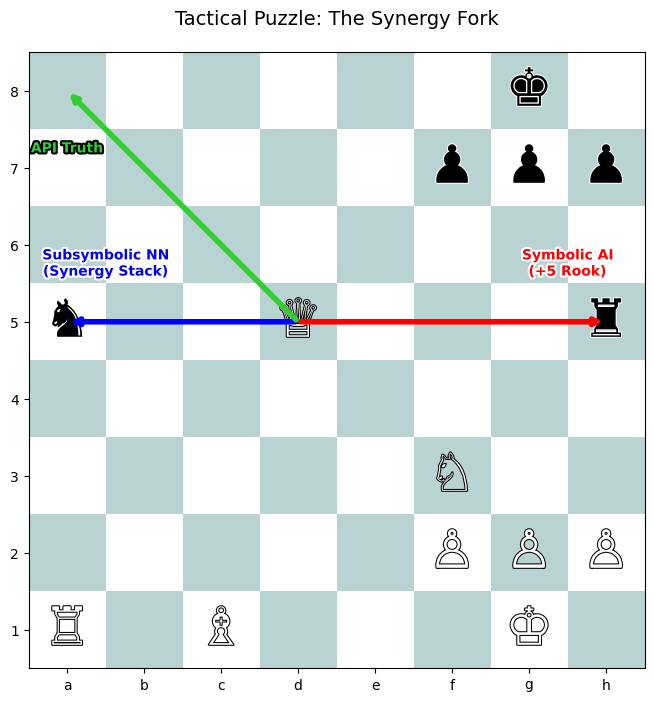

In [12]:
puzzle = TacticalChessPuzzle()
puzzle.run()
